In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset, Dataset

In [3]:
# train_0_dir = "/kaggle/input/competitions/image-detection-for-fires/train/0"
# train_1_dir = "/kaggle/input/competitions/image-detection-for-fires/train/1"
train_dir = "/kaggle/input/competitions/image-detection-for-fires/train"
test_dir = "/kaggle/input/competitions/image-detection-for-fires/test"
testImgs = sorted(glob.glob(f'{test_dir}/*.png'))

In [4]:
# trainImgs_0 = sorted(glob.glob(f'{train_0_dir}/*.png'))

# trainImgs_1 = sorted(glob.glob(f'{train_1_dir}/*.png'))


In [5]:
# testImgs

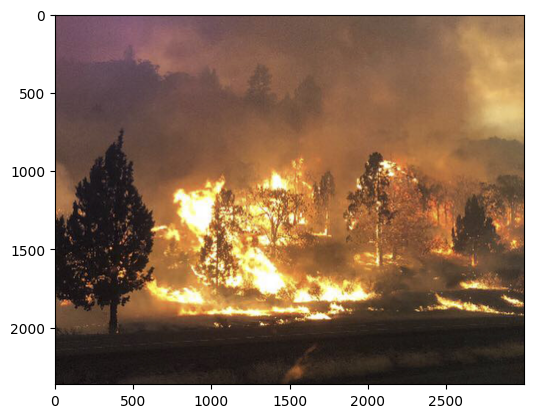

In [6]:
plt.imshow(Image.open(testImgs[4]))
plt.show()

In [7]:
# transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
train_transform = transforms.Compose([transforms.ToTensor(), transforms.Resize((224, 224))])



In [8]:
# train_dataset = datasets.CIFAR10(root='/kaggle/input/competitions/image-detection-for-fires/train/0', train=True, download=True, transform=transform)

In [9]:
# train_ds = datasets.ImageFolder(train_dir, transform=augment)

# CLASS_NAMES = train_ds.classes
# label2idx = train_ds.class_to_idx
# idx2label = {i : c for c, i in label2idx.items()}

In [10]:
train_dataset = datasets.ImageFolder(train_dir, transform= train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [11]:
CLASS_NAMES = train_dataset.classes

In [12]:
class TestDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

In [13]:
# test_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
test_transform = transforms.Compose([transforms.ToTensor(), transforms.Resize((224, 224))])

In [14]:
test_dataset = TestDataset(testImgs, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
# Define CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

device = torch.device("cpu")
model = SimpleCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [16]:
# Train the model
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()


In [17]:

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        correct += (out.argmax(1) == lbls).sum().item()
        total += lbls.size(0)

    # To print accuracy
    print(f"Epoch {epoch + 1}/{EPOCHS} accuracy {correct/total:.3f}")

Epoch 1/5 accuracy 0.818
Epoch 2/5 accuracy 0.914
Epoch 3/5 accuracy 0.894
Epoch 4/5 accuracy 0.963
Epoch 5/5 accuracy 0.960


In [18]:
label2idx = train_dataset.class_to_idx
idx2label = {i: c for c, i in label2idx.items()}

In [19]:
# To evaluate model
model.eval()
predictions = []

with torch.no_grad():
    for imgs in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().tolist()
        predictions += [idx2label[p] for p in preds]

print(f'Generated {len(predictions)} predictions')

Generated 300 predictions


In [20]:
# Create submission
# Extract IDs from name of images in test set
imgIDs = [p.split("/")[-1] for p in testImgs]

submission = pd.DataFrame({"ID": imgIDs, "Label": predictions})
submission.to_csv("submission.csv", index=False)

print(submission.head())
print(f"submission.csv saved - {len(submission)} rows")

         ID Label
0  0001.png     1
1  0002.png     0
2  0003.png     1
3  0004.png     1
4  0005.png     1
submission.csv saved - 300 rows
